### Compare planned (GTFS) vs actual (SIRI) bus rides

This notebook unifies the two companion notebooks:
- `load gtfs timetable to pandas dataframe.ipynb` (the *planned* schedule)
- `load siri vehicle locations to pandas dataframe.ipynb` (the *actual* recorded GPS locations)

All the parameters that both data sources need (dates, hours, bus line, operator) are wired **once** in the configuration cell below, then reused everywhere. The last two cells plot the planned route and the actual driven route together - first as a static chart, then as an interactive map - both colored by the same time scale, so you can visually compare schedule vs reality (including delays).

Requires `pip install open-bus-stride-client folium branca`.


In [1]:
!pip install open-bus-stride-client folium branca


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import datetime

import pandas as pd
from dateutil import tz

pd.options.display.max_columns = 1000
pd.options.display.max_colwidth = 1000

import stride

### Configuration

Edit these once - every cell below reuses them. `LINE_REF` and `OPERATOR_REF` identify one specific route variant (see the lookup cell right after this one to find them for a different line/operator/date).

`REQUEST_LIMIT` is passed explicitly as a `limit` query parameter on every API call below (capped at the API's own hard maximum of 15000). This matters: `stride.iterate`'s own `limit=` argument only caps how many items it yields *client-side* - it does **not** get sent to the server. Without an explicit `limit` inside the request params, the server silently defaults to ~100 rows, which quietly truncates results for any window wide enough to span more than one ride - producing a partial planned route and an actual trace cut down to a random tail-end slice, which look like nonsense when compared (e.g. a fake multi-hour "delay" that's really just missing data).

In [21]:
# ---- bus line / operator ----
AGENCY_NAME = 'דן'       # operator display name, used only by the lookup cell below
ROUTE_SHORT_NAME = 5      # bus line number (e.g. "5"), used only by the lookup cell below
# LINE_REF = '32055'        # specific route variant - one line number can have several, see lookup cell below
# LINE_REF = '2259'
LINE_REF = '2261'
OPERATOR_REF = 5          # operator_ref / siri_route__operator_ref for LINE_REF

# ---- date & time window ----
SERVICE_DATE = datetime.date(2026, 7, 29)
HOUR_FROM = 8
HOUR_TO = 11

# ---- request size (see note above) ----
REQUEST_LIMIT = 15000

# ---- derived values used by every query below (no need to edit) ----
TZ = tz.gettz('Israel')
TIME_FROM = datetime.datetime.combine(SERVICE_DATE, datetime.time(HOUR_FROM), tzinfo=TZ)
TIME_TO = datetime.datetime.combine(SERVICE_DATE, datetime.time(HOUR_TO), tzinfo=TZ)
DATE_FROM_STR = SERVICE_DATE.isoformat()
DATE_TO_STR = (SERVICE_DATE + datetime.timedelta(days=1)).isoformat()

def localize_dates(data, dt_columns=None):
    data = data.copy()
    for c in (dt_columns or []):
        data[c] = pd.to_datetime(data[c]).dt.tz_convert('Israel')
    return data

### (Optional) Find LINE_REF / OPERATOR_REF for a different line

As each `route_short_name` (bus line number) can have a few routes (`line_ref`, mainly one per driving direction/variant), look them up here and copy the ones you want into the configuration cell above.

In [22]:
pd.DataFrame(stride.get('/gtfs_routes/list', {
    'route_short_name': ROUTE_SHORT_NAME,
    'operator_refs': OPERATOR_REF,
    'agency_name': AGENCY_NAME,
    'date_from': DATE_FROM_STR,
    'date_to': DATE_TO_STR,
    'limit': REQUEST_LIMIT,
}))

,id,date,line_ref,operator_ref,route_short_name,route_long_name,route_mkt,route_direction,route_alternative,agency_name,route_type
0,9334460,2026-07-29,2259,5,5,ת. רכבת תל אביב סבידור/על פרשת דרכים-תל אביב יפו<->מסוף הלוחמים/משרד הרישוי-תל אביב יפו-10,25005,1,0,דן,3
1,9334461,2026-07-29,2261,5,5,משרד הרישוי/הלוחמים-חולון<->ת. רכבת תל אביב - סבידור/הורדה-תל אביב יפו-20,25005,2,0,דן,3
2,9334462,2026-07-29,2262,5,5,אזור התעשייה-בני ברק<->בית העלמין/חזון אי''ש-בני ברק-10,26005,1,0,דן,3
3,9334463,2026-07-29,2263,5,5,בית העלמין/חזון אי''ש-בני ברק<->אזור התעשייה-בני ברק-20,26005,2,0,דן,3
4,9338796,2026-07-29,32055,5,5,אזור התעשייה-בני ברק<->אזור התעשייה-בני ברק-11,26005,1,1,דן,3
5,9340293,2026-07-30,2259,5,5,ת. רכבת תל אביב סבידור/על פרשת דרכים-תל אביב יפו<->מסוף הלוחמים/משרד הרישוי-תל אביב יפו-10,25005,1,0,דן,3
6,9340294,2026-07-30,2261,5,5,משרד הרישוי/הלוחמים-חולון<->ת. רכבת תל אביב - סבידור/הורדה-תל אביב יפו-20,25005,2,0,דן,3
7,9340295,2026-07-30,2262,5,5,אזור התעשייה-בני ברק<->בית העלמין/חזון אי''ש-בני ברק-10,26005,1,0,דן,3
8,9340296,2026-07-30,2263,5,5,בית העלמין/חזון אי''ש-בני ברק<->אזור התעשייה-בני ברק-20,26005,2,0,דן,3
9,9344642,2026-07-30,32055,5,5,אזור התעשייה-בני ברק<->אזור התעשייה-בני ברק-11,26005,1,1,דן,3


### Get the planned GTFS timetable

Documentation: https://open-bus-stride-api.hasadna.org.il/docs#/

In [23]:
gtfs_timetable = pd.DataFrame(stride.iterate('/route_timetable/list', {
    'line_refs': LINE_REF,
    'planned_start_time_date_from': TIME_FROM,
    'planned_start_time_date_to': TIME_TO,
    'order_by': 'gtfs_line_start_time, planned_arrival_time',
    'limit': REQUEST_LIMIT,
}, limit=REQUEST_LIMIT))

# gtfs_timetable = localize_dates(gtfs_timetable, ['planned_arrival_time', 'gtfs_line_start_time'])

gtfs_timetable.shape

(851, 9)

### Get the actual SIRI vehicle locations

Same `LINE_REF`, `OPERATOR_REF` and time window as above, so the two dataframes are directly comparable.

In [24]:
siri_locations = pd.DataFrame(stride.iterate('/siri_vehicle_locations/list', {
    'siri_routes__line_ref': LINE_REF,
    'siri_routes__operator_ref': OPERATOR_REF,
    'siri_rides__schedualed_start_time_from': TIME_FROM,
    'siri_rides__schedualed_start_time_to': TIME_TO,
    'order_by': 'recorded_at_time desc',
    'limit': REQUEST_LIMIT,
}, limit=REQUEST_LIMIT))

siri_locations = localize_dates(siri_locations, ['recorded_at_time', 'siri_ride__scheduled_start_time'])

siri_locations.shape

(484, 22)

### Match one ride instance between the two dataframes

GTFS's `gtfs_line_start_time` and SIRI's `siri_ride__scheduled_start_time` both identify the ride's scheduled departure, so a matching value in both means we're looking at the same ride - one planned in GTFS, the other actually driven per SIRI (SIRI's own `siri_ride__gtfs_ride_id` join column exists for this too, but is not populated in this API's data, so we match on scheduled start time instead). If none match, widen `HOUR_FROM`/`HOUR_TO` (or change `SERVICE_DATE`) in the configuration cell - SIRI data availability is sparse for some dates/lines.

In [25]:
common_starts = sorted(
    set(gtfs_timetable['gtfs_line_start_time']) & set(siri_locations['siri_ride__scheduled_start_time'])
)
assert common_starts, (
    "No ride has both planned and actual data in this window - "
    "widen HOUR_FROM/HOUR_TO or change SERVICE_DATE in the configuration cell"
)
matched_start = common_starts[0]

plan = gtfs_timetable[gtfs_timetable['gtfs_line_start_time'] == matched_start].sort_values('planned_arrival_time')
actual = siri_locations[siri_locations['siri_ride__scheduled_start_time'] == matched_start].sort_values('recorded_at_time')

matched_start, plan.shape, actual.shape

(Timestamp('2026-07-29 05:04:00+0000', tz='UTC'), (37, 9), (28, 22))

### Plot planned vs actual on a single time axis

The planned route (dashed line, hollow `'o'` markers) and the actual driven route (solid line, filled `'o'` markers) share one colormap/colorbar mapped to actual clock time - so color directly compares *when* the bus was planned to be somewhere against *when* it actually was there.

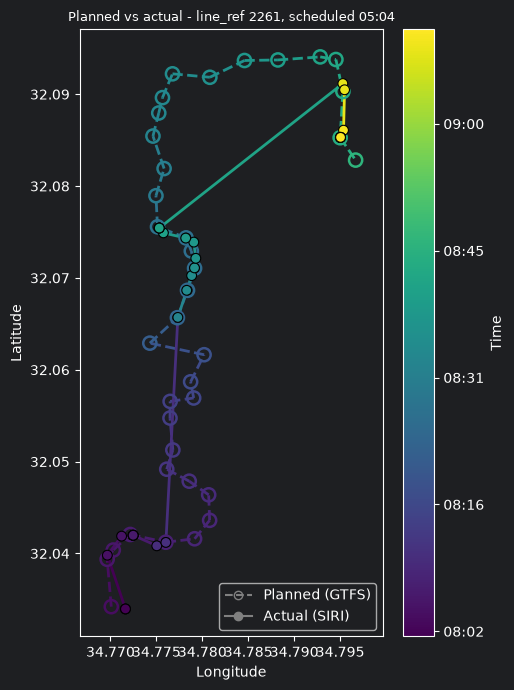

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

def line_segments(lon, lat):
    points = np.column_stack([lon, lat]).reshape(-1, 1, 2)
    return np.concatenate([points[:-1], points[1:]], axis=1)

# one shared time scale across both traces, so color means the same thing for plan and actual
all_times = mdates.date2num(pd.concat([plan['planned_arrival_time'], actual['recorded_at_time']]))
norm = plt.Normalize(all_times.min(), all_times.max())
cmap = plt.get_cmap('viridis')

xs = pd.concat([plan['lon'], actual['lon']])
ys = pd.concat([plan['lat'], actual['lat']])
pad = 0.003
# size the figure to match the lon/lat extent's aspect ratio, otherwise ax.set_aspect('equal')
# shrinks the axes box inside a mismatched figure and leaves large blank margins
lon_span = (xs.max() - xs.min()) + 2 * pad
lat_span = (ys.max() - ys.min()) + 2 * pad
fig_height = 7
fig_width = max(5, fig_height * lon_span / lat_span)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

plan_times = mdates.date2num(plan['planned_arrival_time'])
plan_lc = LineCollection(line_segments(plan['lon'].to_numpy(), plan['lat'].to_numpy()),
                          cmap=cmap, norm=norm, linestyle='dashed', linewidth=2)
plan_lc.set_array(plan_times[:-1])
ax.add_collection(plan_lc)
ax.scatter(plan['lon'], plan['lat'], facecolors='none', edgecolors=cmap(norm(plan_times)),
           linewidths=1.8, s=90, marker='o', zorder=3)

actual_times = mdates.date2num(actual['recorded_at_time'])
actual_lc = LineCollection(line_segments(actual['lon'].to_numpy(), actual['lat'].to_numpy()),
                            cmap=cmap, norm=norm, linestyle='solid', linewidth=2)
actual_lc.set_array(actual_times[:-1])
ax.add_collection(actual_lc)
ax.scatter(actual['lon'], actual['lat'], c=actual_times, cmap=cmap, norm=norm,
           marker='o', edgecolor='black', linewidths=0.8, s=50, zorder=3)

ax.set_xlim(xs.min() - pad, xs.max() + pad)
ax.set_ylim(ys.min() - pad, ys.max() + pad)
ax.set_aspect('equal')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f"Planned vs actual - line_ref {LINE_REF}, scheduled {matched_start.strftime('%H:%M')}",
             fontsize=9, wrap=True)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=TZ))
cbar.set_label('Time')

legend_handles = [
    Line2D([0], [0], color='gray', linestyle='dashed', marker='o', markerfacecolor='none', label='Planned (GTFS)'),
    Line2D([0], [0], color='gray', linestyle='solid', marker='o', markerfacecolor='gray', label='Actual (SIRI)'),
]
ax.legend(handles=legend_handles, loc='lower right')
fig.tight_layout()

plt.show()

### Plot planned vs actual on an actual map

Same comparison, on an interactive [folium](https://python-visualization.github.io/folium/) map (Leaflet + OpenStreetMap tiles - no API key required, unlike Google Maps tiles which need a billed Google Cloud API key). Dashed hollow markers are the planned stops, solid filled markers are the actual recorded pings - click either for the exact time.

In [27]:
import folium
import branca.colormap as cm

# elapsed minutes since the earliest of BOTH plan and actual - one shared, human-readable time axis
t0 = min(plan['planned_arrival_time'].min(), actual['recorded_at_time'].min())
plan_elapsed = (plan['planned_arrival_time'] - t0).dt.total_seconds() / 60
actual_elapsed = (actual['recorded_at_time'] - t0).dt.total_seconds() / 60

colormap = cm.LinearColormap(
    colors=['#440154', '#31688e', '#35b779', '#fde725'],  # viridis-style gradient
    vmin=0, vmax=max(plan_elapsed.max(), actual_elapsed.max())
)
colormap.caption = f"Minutes since {t0.strftime('%H:%M')} ({t0.strftime('%d %b')})"

# explicit width/height (not the default responsive iframe) - some notebook front-ends
# (e.g. VS Code) collapse folium's default 0-height responsive container to nothing
combined_map = folium.Map(location=[ys.mean(), xs.mean()], zoom_start=14, tiles='OpenStreetMap',
                           width=900, height=600)

plan_coords = list(zip(plan['lat'], plan['lon']))
for (lat1, lon1), (lat2, lon2), t in zip(plan_coords[:-1], plan_coords[1:], plan_elapsed.iloc[:-1]):
    folium.PolyLine([(lat1, lon1), (lat2, lon2)], color=colormap(t), weight=4, opacity=0.9,
                     dash_array='6,6').add_to(combined_map)
for (lat, lon), t, arr in zip(plan_coords, plan_elapsed, plan['planned_arrival_time']):
    folium.CircleMarker(
        location=(lat, lon), radius=6, color=colormap(t), weight=2, fill=False,
        popup=f"Planned: {arr.strftime('%H:%M:%S')}",
    ).add_to(combined_map)

actual_coords = list(zip(actual['lat'], actual['lon']))
for (lat1, lon1), (lat2, lon2), t in zip(actual_coords[:-1], actual_coords[1:], actual_elapsed.iloc[:-1]):
    folium.PolyLine([(lat1, lon1), (lat2, lon2)], color=colormap(t), weight=4, opacity=0.9).add_to(combined_map)
for (lat, lon), t, rec in zip(actual_coords, actual_elapsed, actual['recorded_at_time']):
    folium.CircleMarker(
        location=(lat, lon), radius=6, color='black', weight=1, fill=True,
        fill_color=colormap(t), fill_opacity=1.0,
        popup=f"Actual: {rec.strftime('%H:%M:%S')}",
    ).add_to(combined_map)

colormap.add_to(combined_map)
combined_map

### Schedule adherence: stop vs. time

A classic "stringline" diagram: x-axis is stop sequence along the route, y-axis is time. The planned schedule is a smooth line by construction; each actual SIRI GPS ping is snapped to its nearest planned stop (by straight-line lon/lat distance) so it can be placed on the same x-axis - the vertical gap between an actual dot and the planned line at that stop is the delay. Note: for a route that loops back near its own path (as this one does around stop ~38-50), nearest-stop snapping can occasionally pick the wrong pass of the loop - a limitation of proximity-based matching, not a data error.

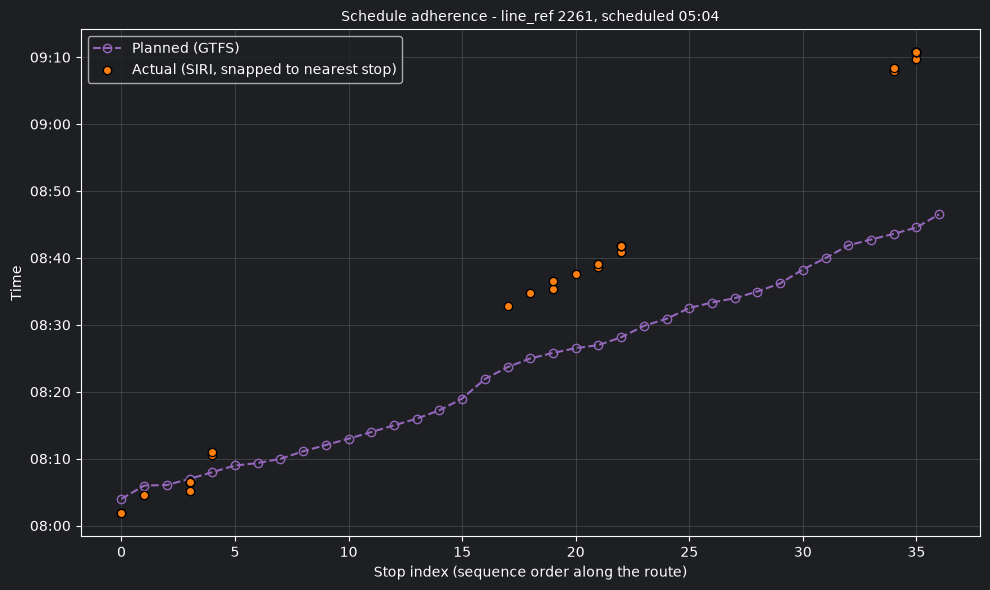

In [28]:
plan_by_seq = plan.reset_index(drop=True)
actual_by_seq = actual.reset_index(drop=True)

# snap each actual GPS ping to its nearest planned stop (by straight-line lon/lat distance),
# so both series can share a "stop index" x-axis
plan_xy = plan_by_seq[['lon', 'lat']].to_numpy()
actual_xy = actual_by_seq[['lon', 'lat']].to_numpy()
dists = np.linalg.norm(actual_xy[:, None, :] - plan_xy[None, :, :], axis=2)
nearest_stop_idx = dists.argmin(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(len(plan_by_seq)), plan_by_seq['planned_arrival_time'], linestyle='dashed', marker='o',
        markerfacecolor='none', color='tab:purple', label='Planned (GTFS)')
ax.scatter(nearest_stop_idx, actual_by_seq['recorded_at_time'], marker='o', color='tab:orange',
           edgecolor='black', zorder=3, label='Actual (SIRI, snapped to nearest stop)')

ax.set_xlabel('Stop index (sequence order along the route)')
ax.set_ylabel('Time')
ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=TZ))
ax.set_title(f"Schedule adherence - line_ref {LINE_REF}, scheduled {matched_start.strftime('%H:%M')}", fontsize=10)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
fig.tight_layout()

plt.show()